# E-Commerce Sales Analytics (EDA)
This notebook explores sales performance, customer segments,
and product trends using data visualization.

In [2]:
import numpy as np
import pandas as pd

In [8]:
df = pd.read_csv("../data/superstore.csv", encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


In [9]:
df.shape

(51290, 24)

In [13]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country',
       'Postal Code', 'Market', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit', 'Shipping Cost', 'Order Priority'],
      dtype='object')

In [10]:
df.info

<bound method DataFrame.info of        Row ID         Order ID  Order Date   Ship Date       Ship Mode  \
0       32298   CA-2012-124891  31-07-2012  31-07-2012        Same Day   
1       26341    IN-2013-77878  05-02-2013  07-02-2013    Second Class   
2       25330    IN-2013-71249  17-10-2013  18-10-2013     First Class   
3       13524  ES-2013-1579342  28-01-2013  30-01-2013     First Class   
4       47221     SG-2013-4320  05-11-2013  06-11-2013        Same Day   
...       ...              ...         ...         ...             ...   
51285   29002    IN-2014-62366  19-06-2014  19-06-2014        Same Day   
51286   35398   US-2014-102288  20-06-2014  24-06-2014  Standard Class   
51287   40470   US-2013-155768  02-12-2013  02-12-2013        Same Day   
51288    9596   MX-2012-140767  18-02-2012  22-02-2012  Standard Class   
51289    6147   MX-2012-134460  22-05-2012  26-05-2012    Second Class   

      Customer ID     Customer Name      Segment           City  \
0        RH-

In [14]:
df.describe

<bound method NDFrame.describe of        Row ID         Order ID  Order Date   Ship Date       Ship Mode  \
0       32298   CA-2012-124891  31-07-2012  31-07-2012        Same Day   
1       26341    IN-2013-77878  05-02-2013  07-02-2013    Second Class   
2       25330    IN-2013-71249  17-10-2013  18-10-2013     First Class   
3       13524  ES-2013-1579342  28-01-2013  30-01-2013     First Class   
4       47221     SG-2013-4320  05-11-2013  06-11-2013        Same Day   
...       ...              ...         ...         ...             ...   
51285   29002    IN-2014-62366  19-06-2014  19-06-2014        Same Day   
51286   35398   US-2014-102288  20-06-2014  24-06-2014  Standard Class   
51287   40470   US-2013-155768  02-12-2013  02-12-2013        Same Day   
51288    9596   MX-2012-140767  18-02-2012  22-02-2012  Standard Class   
51289    6147   MX-2012-134460  22-05-2012  26-05-2012    Second Class   

      Customer ID     Customer Name      Segment           City  \
0        R

In [15]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

C:\Users\Tirupati\AppData\Local\Temp\ipykernel_11268\312075123.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Order Date'] = pd.to_datetime(df['Order Date'])
C:\Users\Tirupati\AppData\Local\Temp\ipykernel_11268\312075123.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Ship Date'] = pd.to_datetime(df['Ship Date'])


In [24]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Day'] = df['Order Date'].dt.day

In [25]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country',
       'Postal Code', 'Market', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit', 'Shipping Cost', 'Order Priority', 'Year', 'Month', 'Day',
       'Profit Margin'],
      dtype='object')

In [26]:
df['Profit Margin'] = df['Profit'] / df['Sales']

In [27]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
City              0
State             0
Country           0
Postal Code       0
Market            0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
Shipping Cost     0
Order Priority    0
Year              0
Month             0
Day               0
Profit Margin     0
dtype: int64

In [28]:
df.dropna(inplace=True)

# Data visualization

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

## Monthly Sales Trend

This graph shows how sales change over time.
It helps identify seasonal patterns and months with high or low revenue.
Businesses use this insight for planning marketing campaigns and inventory.

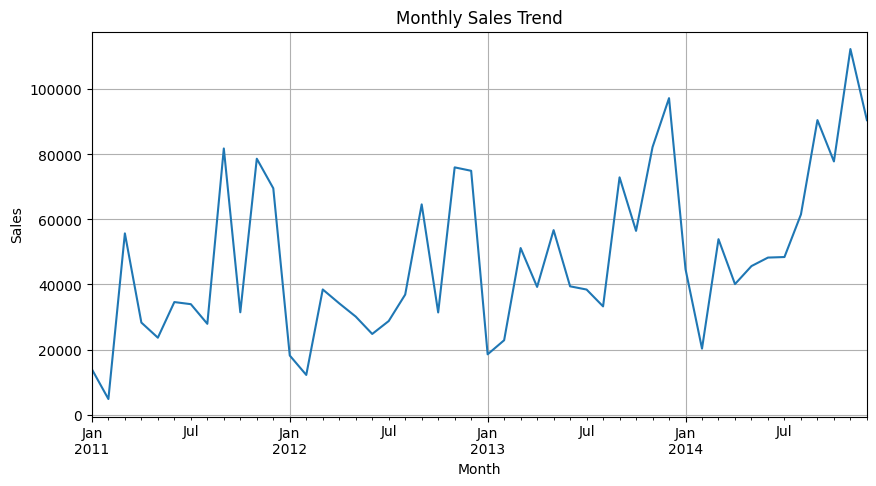

In [32]:
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()

monthly_sales.plot(figsize=(10,5))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

## Category Wise Sales

This bar chart compares total sales across different product categories.
It helps businesses identify which categories generate the most revenue.

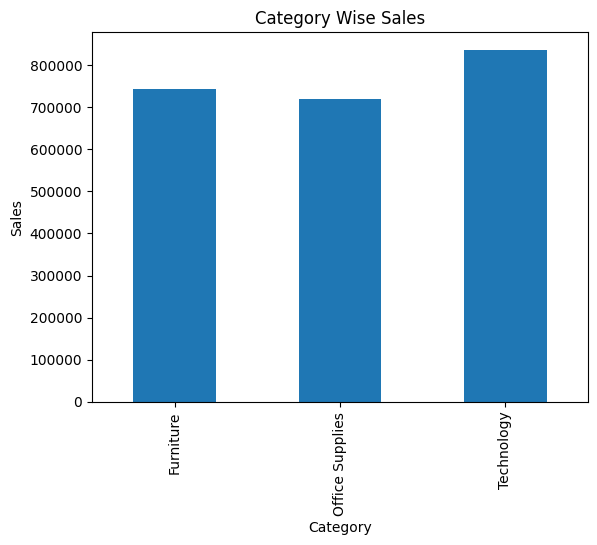

In [33]:
category_sales = df.groupby("Category")["Sales"].sum()

category_sales.plot(kind="bar")
plt.title("Category Wise Sales")
plt.ylabel("Sales")
plt.show()

## Sub Category Sales

This chart analyzes sales at the sub-category level.
It helps identify the best selling product types within each category.

Text(0.5, 1.0, 'Sub Category Sales')

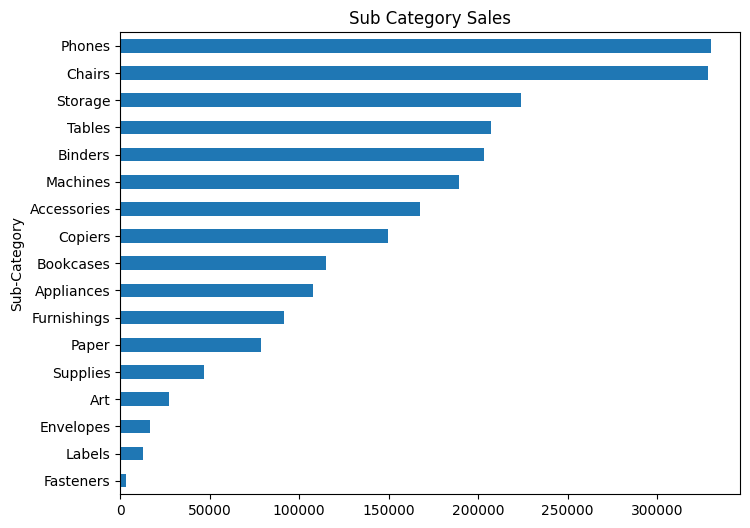

In [35]:
sub_sales = df.groupby("Sub-Category")["Sales"].sum().sort_values()

sub_sales.plot(kind="barh", figsize=(8,6))
plt.title("Sub Category Sales")

## Region Wise Sales Distribution

This chart shows how sales are distributed across different regions.
It helps companies identify strong and weak markets.

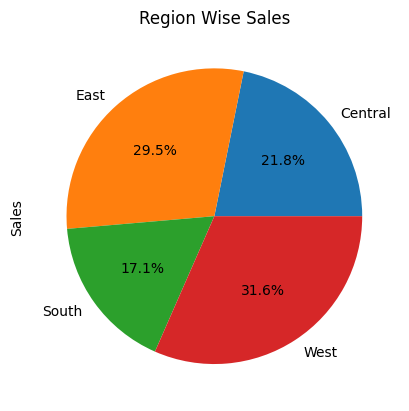

In [36]:
region_sales = df.groupby("Region")["Sales"].sum()

region_sales.plot(kind="pie", autopct="%1.1f%%")
plt.title("Region Wise Sales")
plt.show()

## Top 10 Products by Sales

This visualization shows the top performing products based on total sales.
It helps businesses understand which products drive the most revenue.

Text(0.5, 1.0, 'Top 10 Products')

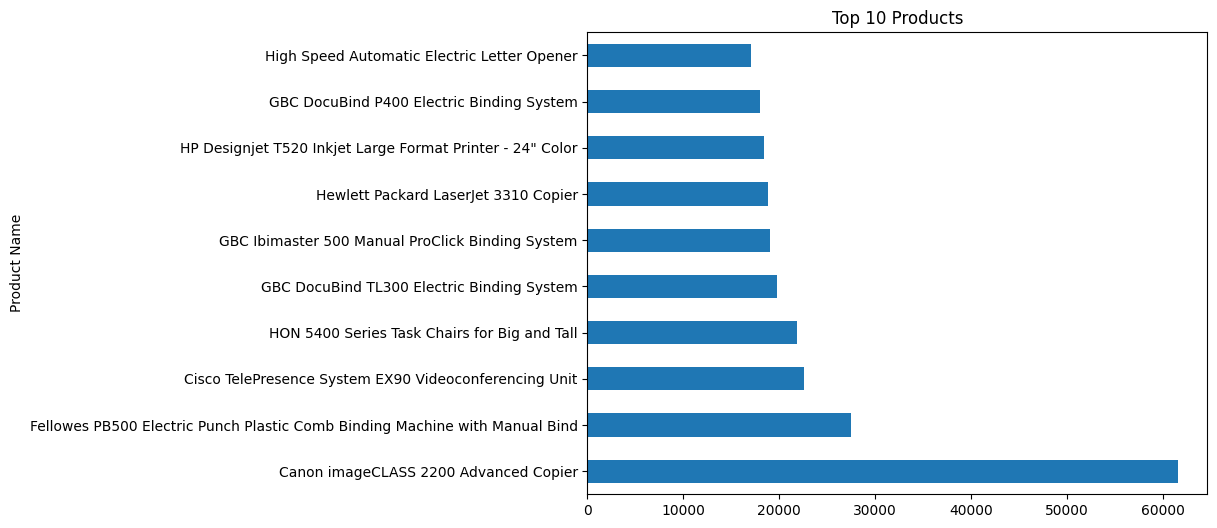

In [38]:
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

top_products.plot(kind="barh", figsize=(8,6))
plt.title("Top 10 Products")

## Discount vs Profit Relationship

This scatter plot shows how discounts affect profit.
It helps businesses analyze whether higher discounts reduce profitability.

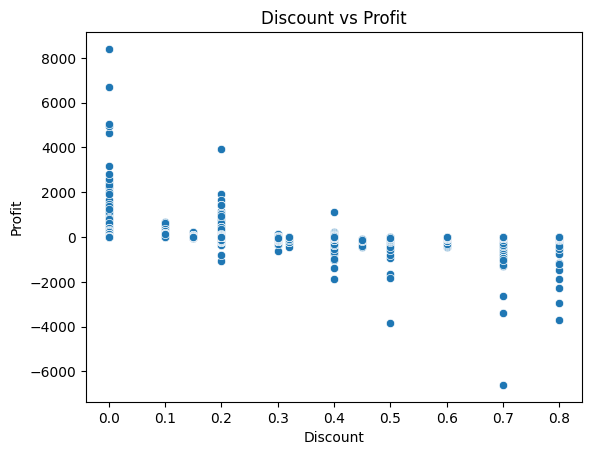

In [39]:
sns.scatterplot(x=df["Discount"], y=df["Profit"])
plt.title("Discount vs Profit")
plt.show()

## Sales by Customer Segment

This chart compares total sales across different customer segments.
It helps businesses understand which type of customers generate the most revenue.

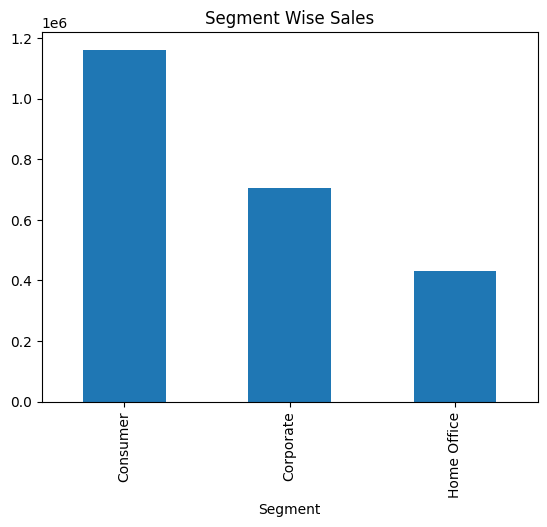

In [40]:
segment_sales = df.groupby("Segment")["Sales"].sum()

segment_sales.plot(kind="bar")
plt.title("Segment Wise Sales")
plt.show()

## Shipping Mode Analysis

This chart shows which shipping methods customers use the most.
It helps businesses optimize delivery operations.

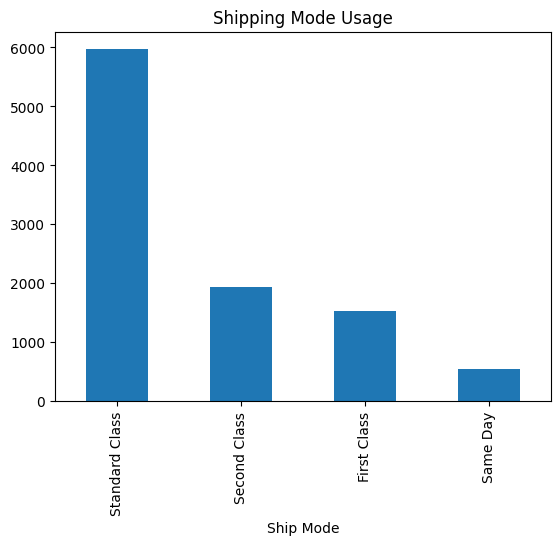

In [42]:
ship_mode = df["Ship Mode"].value_counts()

ship_mode.plot(kind="bar")
plt.title("Shipping Mode Usage")
plt.show()

## Profit by Category

This chart compares profit generated by different product categories.
It helps identify which categories contribute most to overall profitability.

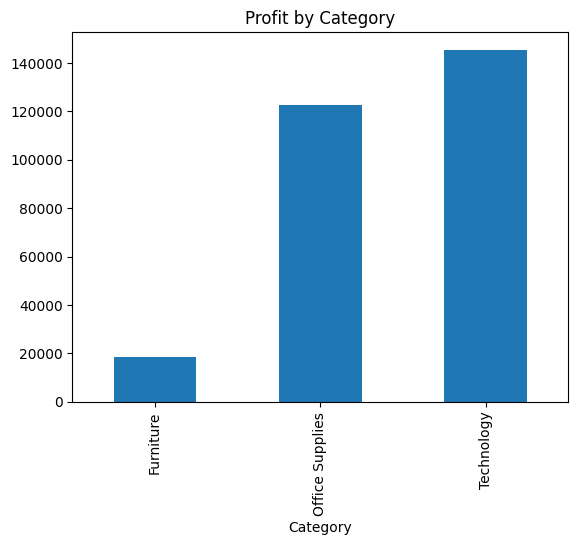

In [43]:
profit_category = df.groupby("Category")["Profit"].sum()

profit_category.plot(kind="bar")
plt.title("Profit by Category")
plt.show()

## Sales Distribution

This histogram shows the distribution of sales values.
It helps analyze whether most orders have low or high sales amounts.

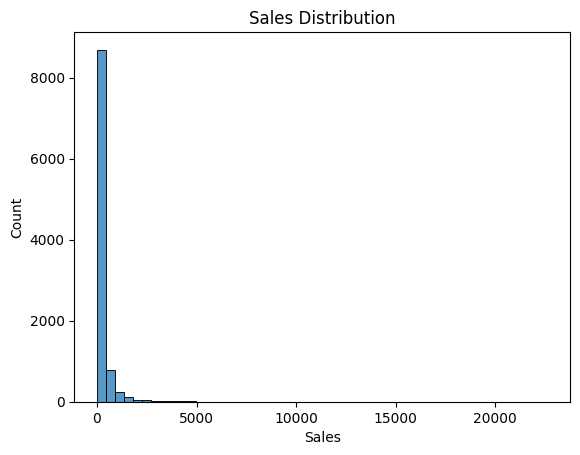

In [44]:
sns.histplot(df["Sales"], bins=50)
plt.title("Sales Distribution")
plt.show()

## Top Customers by Sales

This analysis identifies the customers who generate the highest revenue.
It helps businesses focus on high-value customers and improve retention strategies.

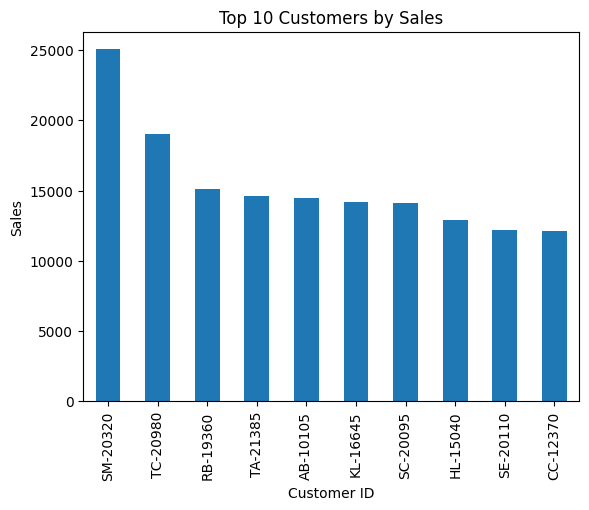

In [45]:
top_customers = df.groupby("Customer ID")["Sales"].sum().sort_values(ascending=False).head(10)

top_customers.plot(kind="bar")
plt.title("Top 10 Customers by Sales")
plt.ylabel("Sales")
plt.show()


## Customer Order Frequency

This chart shows how many orders each customer places.
It helps identify loyal and repeat customers.

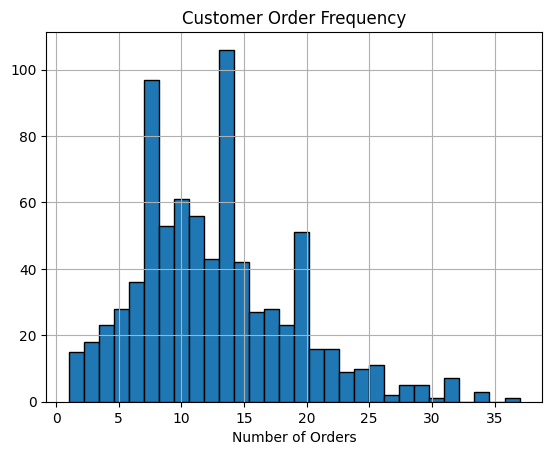

In [52]:
order_frequency = df.groupby("Customer ID")["Order ID"].count()

order_frequency.hist(bins=30,edgecolor='black')
plt.title("Customer Order Frequency")
plt.xlabel("Number of Orders")
plt.show()

## Repeat vs New Customers

This analysis shows how many customers place multiple orders
versus customers who only purchase once.

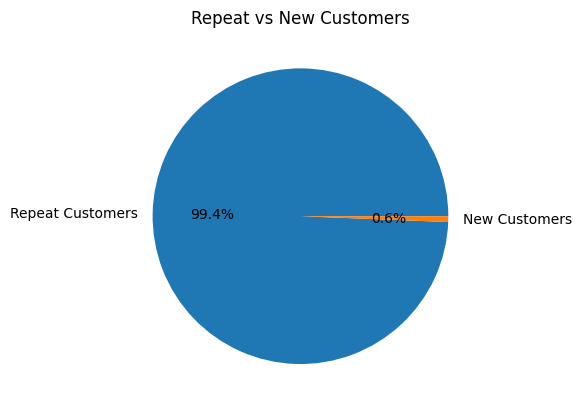

In [54]:
customer_orders = df.groupby("Customer ID")["Order ID"].count()

repeat = (customer_orders > 1).sum()
new = (customer_orders == 1).sum()

labels = ["Repeat Customers", "New Customers"]
values = [repeat, new]

plt.pie(values, labels=labels, autopct="%1.1f%%")
plt.title("Repeat vs New Customers")
plt.show()

## RFM Customer Segmentation

RFM analysis is used to segment customers based on their
purchase behavior.

* R = Recency (last purchase)
* F = Frequency (number of orders)
* M = Monetary (total spending)

In [59]:
import datetime as dt

today = df['Order Date'].max()

rfm = df.groupby("Customer ID").agg({
    "Order Date": lambda x: (today - x.max()).days,
    "Order ID": "count",
    "Sales": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
AA-10315,184,11,5563.560
AA-10375,19,15,1056.390
AA-10480,259,12,1790.512
AA-10645,55,18,5086.935
AB-10015,415,6,886.156


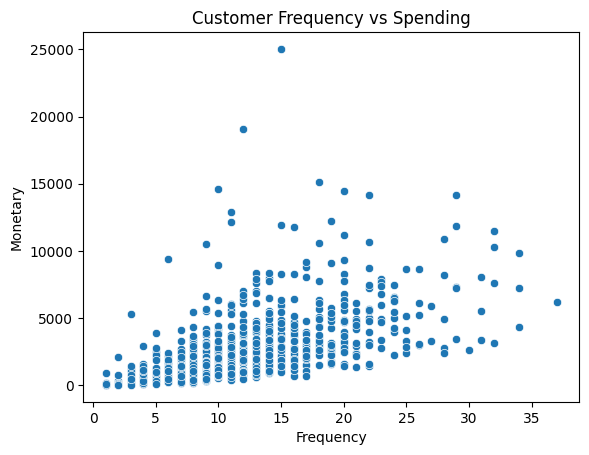

In [60]:
sns.scatterplot(data=rfm, x="Frequency", y="Monetary")
plt.title("Customer Frequency vs Spending")
plt.show()